In [1]:
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from PIL import Image


def set_plot_style():
    """A clean, paper-like matplotlib style (Nature-ish)."""

    palette = [
        "#1F77B4",
        "#FF7F0E",
        "#2CA02C",
        "#D62728",
        "#9467BD",
        "#8C564B",
        "#E377C2",
        "#7F7F7F",
        "#BCBD22",
        "#17BECF",
    ]

    plt.rcParams.update(
        {
            "font.family": "sans-serif",
            "font.sans-serif": ["Arial", "DejaVu Sans"],
            "svg.fonttype": "none",
            "font.size": 13,
            "axes.spines.right": False,
            "axes.spines.top": False,
            "axes.linewidth": 1.5,
            "axes.grid": False,
            "axes.prop_cycle": plt.cycler(color=palette),
            "xtick.direction": "out",
            "ytick.direction": "out",
            "lines.linewidth": 2.0,
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
        }
    )


set_plot_style()

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
try:
    torch.set_num_threads(1)
except Exception:
    pass

print(f"PyTorch version: {torch.__version__}")
print(f"Default device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch version: 2.6.0+cu124
Default device: cuda


## 2 卷积和池化层
## 2.1 理论计算题

输入张量尺寸为 $3\times 32\times 32$（通道数 $\times$ 高 $\times$ 宽）。卷积层包含 $16$ 个大小为 $3\times 5\times 5$ 的卷积核，填充 $P=2$，步幅 $S=2$。

### 1. 输出特征图尺寸

对空间维（高或宽）使用公式

$$
H_{\text{out}}=\left\lfloor\frac{H+2P-K}{S}\right\rfloor+1.
$$

代入 $H=32,\,P=2,\,K=5,\,S=2$：

$$
H_{\text{out}}=\left\lfloor\frac{32+4-5}{2}\right\rfloor+1=\left\lfloor\frac{31}{2}\right\rfloor+1=15+1=16.
$$

宽方向同理，因此输出特征图尺寸为

$$
\boxed{16\times 16\times 16\quad(\text{通道数}\times\text{高}\times\text{宽})}.
$$

### 2. 单个输出像素需要的乘法次数

对**某一个输出通道**的**某一个空间位置**，只需使用一个 $3\times 5\times 5$ 卷积核与输入对应局部区域做点积。该局部区域共有

$$
3\times 5\times 5=75
$$

个元素，因此需要 **75 次乘法**（对应 75 次乘加运算中的乘法部分）。

## 2.2 编程题

用基础张量操作实现支持 `stride` 与 `padding` 的二维最大池化前向传播，并与 PyTorch 内置结果对照验证。

In [2]:
def max_pool2d_forward(X, kernel_size, stride=None, padding=0):
    """二维最大池化前向传播（不调用 nn.MaxPool2d）。

    参数
    ------
    X : torch.Tensor, shape (N, C, H, W)
    kernel_size : int
    stride : int, 默认等于 kernel_size
    padding : int, 在四周补 -inf，便于池化窗口覆盖边界
    """
    if stride is None:
        stride = kernel_size
    if X.ndim != 4:
        raise ValueError("X must have shape (N, C, H, W)")

    n, c, h, w = X.shape
    if padding > 0:
        X = F.pad(X, (padding, padding, padding, padding), value=float("-inf"))
        h += 2 * padding
        w += 2 * padding

    out_h = (h - kernel_size) // stride + 1
    out_w = (w - kernel_size) // stride + 1
    if out_h <= 0 or out_w <= 0:
        raise ValueError("kernel/stride/padding produce non-positive output size")

    Y = torch.empty((n, c, out_h, out_w), dtype=X.dtype, device=X.device)
    for i in range(out_h):
        hs = i * stride
        he = hs + kernel_size
        for j in range(out_w):
            ws = j * stride
            we = ws + kernel_size
            window = X[:, :, hs:he, ws:we]
            Y[:, :, i, j] = window.amax(dim=(-1, -2))
    return Y


torch.manual_seed(SEED)
x = torch.randn(2, 3, 8, 8)
cases = [
    {"kernel_size": 2, "stride": 2, "padding": 0},
    {"kernel_size": 3, "stride": 2, "padding": 1},
    {"kernel_size": 2, "stride": 1, "padding": 0},
]

for cfg in cases:
    y_manual = max_pool2d_forward(x, **cfg)
    y_ref = F.max_pool2d(x, **cfg)
    diff = (y_manual - y_ref).abs().max().item()
    print(
        f"kernel={cfg['kernel_size']}, stride={cfg['stride']}, padding={cfg['padding']} "
        f"-> output shape {tuple(y_manual.shape)}, max |diff| = {diff:.3e}"
    )
    assert torch.allclose(y_manual, y_ref), "manual max pooling mismatch"

kernel=2, stride=2, padding=0 -> output shape (2, 3, 4, 4), max |diff| = 0.000e+00
kernel=3, stride=2, padding=1 -> output shape (2, 3, 4, 4), max |diff| = 0.000e+00
kernel=2, stride=1, padding=0 -> output shape (2, 3, 7, 7), max |diff| = 0.000e+00


## 3 LeNet, AlexNet, VGG 和 NiN
## 3.1 理论计算题

设输入、输出通道数均为 $C$，且不考虑偏置。

### 1. 一个 $5\times 5$ 卷积层的参数量

$$
N_{5\times 5}=C\cdot C\cdot 5\cdot 5=\boxed{25C^2}.
$$

### 2. 两个串联 $3\times 3$ 卷积层的总参数量

每层参数量均为 $C^2\cdot 3\cdot 3=9C^2$，因此

$$
N_{3\times 3\times 2}=2\cdot 9C^2=\boxed{18C^2}.
$$

因为 $18C^2<25C^2$，VGG 用两个 $3\times 3$ 卷积代替一个 $5\times 5$ 卷积可以在保持相近感受野的同时显著减少参数量，并增加一层非线性（ReLU），提升表达能力。

## 3.2 编程题

使用 `torch.nn.Sequential` 定义标准 NiN 块：普通卷积 + ReLU + 两个 $1\times 1$ 卷积（每层后接 ReLU）。

In [3]:
def nin_block(in_channels, out_channels, kernel_size, strides, padding):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size, stride=strides, padding=padding),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=1),
        nn.ReLU(inplace=True),
    )


block = nin_block(in_channels=3, out_channels=16, kernel_size=5, strides=1, padding=2)
x = torch.randn(1, 3, 32, 32)
y = block(x)
print(block)
print(f"Input shape:  {tuple(x.shape)}")
print(f"Output shape: {tuple(y.shape)}")

Sequential(
  (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (1): ReLU(inplace=True)
  (2): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (3): ReLU(inplace=True)
  (4): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1))
  (5): ReLU(inplace=True)
)
Input shape:  (1, 3, 32, 32)
Output shape: (1, 16, 32, 32)


## 4 Inception、批量归一化和残差网络
## 4.1 理论计算题

小批量中 4 个样本在同一通道、同一空间位置的特征值为 $x_1=2,\,x_2=4,\,x_3=6,\,x_4=8$。批量归一化参数 $\gamma=2,\,\beta=1,\,\epsilon=0$。

先计算批量均值与方差：

$$
\mu=\frac{2+4+6+8}{4}=5,\qquad
\sigma^2=\frac{(2-5)^2+(4-5)^2+(6-5)^2+(8-5)^2}{4}=\frac{20}{4}=5.
$$

标准化并仿射变换 $y_i=\gamma\hat{x}_i+\beta$，其中 $\hat{x}_i=(x_i-\mu)/\sqrt{\sigma^2+\epsilon}$：

$$
\begin{aligned}
y_1 &= 2\cdot\frac{2-5}{\sqrt{5}}+1 = 1-\frac{6}{\sqrt{5}},\\
y_2 &= 2\cdot\frac{4-5}{\sqrt{5}}+1 = 1-\frac{2}{\sqrt{5}},\\
y_3 &= 2\cdot\frac{6-5}{\sqrt{5}}+1 = 1+\frac{2}{\sqrt{5}},\\
y_4 &= 2\cdot\frac{8-5}{\sqrt{5}}+1 = 1+\frac{6}{\sqrt{5}}.
\end{aligned}
$$

数值近似为

$$
\boxed{y_1\approx -1.683,\; y_2\approx 0.106,\; y_3\approx 1.894,\; y_4\approx 3.683}.
$$

## 4.2 编程题

自定义残差块 `Residual`：两个 $3\times 3$ 卷积 + 批量归一化；当 `use_1x1conv=True` 时，用 $1\times 1$ 卷积调整捷径分支，使 $f(x)+x$ 形状一致。

In [4]:
class Residual(nn.Module):
    def __init__(self, input_channels, num_channels, use_1x1conv=False, strides=1):
        super().__init__()
        self.conv1 = nn.Conv2d(
            input_channels, num_channels, kernel_size=3, padding=1, stride=strides
        )
        self.conv2 = nn.Conv2d(num_channels, num_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(num_channels)
        self.bn2 = nn.BatchNorm2d(num_channels)
        if use_1x1conv:
            self.conv3 = nn.Conv2d(input_channels, num_channels, kernel_size=1, stride=strides)
        else:
            self.conv3 = None

    def forward(self, X):
        Y = F.relu(self.bn1(self.conv1(X)))
        Y = self.bn2(self.conv2(Y))
        if self.conv3 is not None:
            X = self.conv3(X)
        return F.relu(Y + X)


# 通道数一致时，可不使用 1x1 卷积捷径
block_same = Residual(16, 16, use_1x1conv=False, strides=1)
x = torch.randn(2, 16, 32, 32)
y = block_same(x)
print(f"use_1x1conv=False (16->16): {tuple(x.shape)} -> {tuple(y.shape)}")

# 通道数或步幅变化时，需要 1x1 卷积对齐形状
block_proj = Residual(3, 16, use_1x1conv=True, strides=1)
x = torch.randn(2, 3, 32, 32)
y = block_proj(x)
print(f"use_1x1conv=True (3->16): {tuple(x.shape)} -> {tuple(y.shape)}")

block_stride = Residual(3, 16, use_1x1conv=True, strides=2)
x = torch.randn(2, 3, 32, 32)
y = block_stride(x)
print(f"use_1x1conv=True, stride=2: {tuple(x.shape)} -> {tuple(y.shape)}")

use_1x1conv=False (16->16): (2, 16, 32, 32) -> (2, 16, 32, 32)
use_1x1conv=True (3->16): (2, 3, 32, 32) -> (2, 16, 32, 32)
use_1x1conv=True, stride=2: (2, 3, 32, 32) -> (2, 16, 16, 16)


## 5 图像增广、微调和样式迁移
## 5.1 理论计算题

### 1. 为什么底层特征提取层使用较小学习率（甚至冻结），而顶层输出层使用较大学习率？

在 ImageNet 等大规模数据集上预训练后，网络底层卷积层已经学习到边缘、纹理、局部形状等**通用、可迁移**的视觉特征。这些表示对许多下游任务仍然有效，只需做小幅调整。

相反，顶层（尤其是分类头）与源数据集的类别空间强相关，迁移到新任务时必须**重新适配**类别决策边界，因此需要更大的学习率甚至从头训练。

若对底层也使用过大学习率，容易破坏已学到的通用特征，导致微调不稳定、收敛变慢，并在小目标数据集上更容易过拟合。

### 2. 目标数据集很小且与源数据集非常相似时，如何防止过拟合？

可采取以下策略：

1. **冻结大部分骨干网络**，只训练最后几层或分类头。
2. 使用**较小学习率**和**较少训练轮数**，配合早停。
3. 使用适度的**数据增广**（随机裁剪、翻转、颜色扰动等）扩大有效样本量。
4. 对顶层使用 **$L_2$ 权重衰减 / Dropout** 等正则化。
5. 若类别数变化不大，可保留原分类器结构，仅替换最后线性层并少样本微调。

## 5.2 编程题

使用 `torchvision.transforms` 构建图像增广 Pipeline，并以同目录下的 `lena.jpg` 作为示例图像，演示增广后的张量形状与数值范围。

Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.5, 1.5), contrast=(0.5, 1.5), saturation=(0.5, 1.5), hue=None)
    ToTensor()
)
lena.jpg path: F:\1Z_Others\学习资料\深度学习\HW03\lena.jpg
original image size: (512, 512) (width x height)


augmented sample 1: shape=(3, 224, 224), min=0.008, max=1.000


augmented sample 2: shape=(3, 224, 224), min=0.110, max=0.710
augmented sample 3: shape=(3, 224, 224), min=0.251, max=0.827


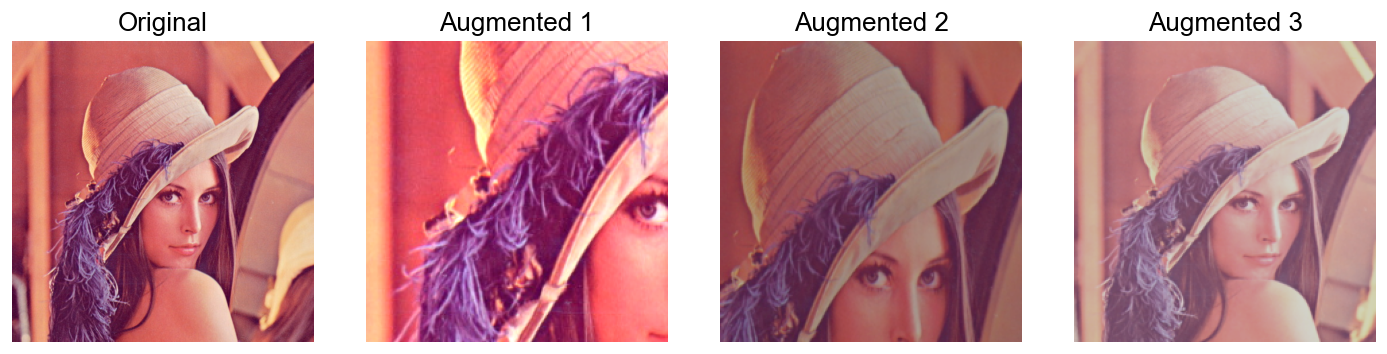

In [5]:
train_augment = transforms.Compose(
    [
        transforms.RandomResizedCrop(224, scale=(0.08, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5),
        transforms.ToTensor(),
    ]
)

print(train_augment)

lena_path = Path("lena.jpg")
if not lena_path.is_file():
    raise FileNotFoundError(
        f"未找到 {lena_path.resolve()}，请将 lena.jpg 放在与本 notebook 相同的 HW03 目录下。"
    )

lena_img = Image.open(lena_path).convert("RGB")
print(f"lena.jpg path: {lena_path.resolve()}")
print(f"original image size: {lena_img.size} (width x height)")

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(lena_img)
axes[0].set_title("Original")
axes[0].axis("off")

for i in range(3):
    tensor = train_augment(lena_img)
    print(
        f"augmented sample {i + 1}: shape={tuple(tensor.shape)}, "
        f"min={tensor.min().item():.3f}, max={tensor.max().item():.3f}"
    )
    axes[i + 1].imshow(tensor.permute(1, 2, 0).numpy())
    axes[i + 1].set_title(f"Augmented {i + 1}")
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

## 6 目标检测、计算机视觉训练技巧
## 6.1 理论计算题

边界框格式为 $[x_1,y_1,x_2,y_2]$（左上角、右下角）。

- 真实框 $A=[10,10,50,50]$
- 预测框 $B=[30,30,70,70]$

交集区域为 $[30,30,50,50]$，宽 $20$、高 $20$，故

$$
|A\cap B|=20\times 20=400.
$$

两框面积均为 $(50-10)^2=1600$，因此

$$
|A\cup B|=1600+1600-400=2800,\qquad
\text{IoU}=\frac{400}{2800}=\boxed{\frac{1}{7}\approx 0.1429}.
$$

## 6.2 编程题

实现标签平滑交叉熵：真实类概率为 $1-\epsilon$，其余类为 $\epsilon/(K-1)$。

In [6]:
def label_smoothing_cross_entropy(logits, labels, num_classes, epsilon=0.1):
    """标签平滑后的交叉熵损失。"""
    if labels.ndim != 1:
        raise ValueError("labels must be 1D class indices")
    if not (0.0 <= epsilon < 1.0):
        raise ValueError("epsilon must be in [0, 1)")
    if num_classes < 2:
        raise ValueError("num_classes must be >= 2 when using label smoothing")

    smooth = epsilon / (num_classes - 1)
    target = torch.full((labels.size(0), num_classes), smooth, device=logits.device, dtype=logits.dtype)
    target.scatter_(1, labels.unsqueeze(1), 1.0 - epsilon)
    log_probs = F.log_softmax(logits, dim=1)
    return -(target * log_probs).sum(dim=1).mean()


torch.manual_seed(SEED)
logits = torch.randn(4, 5)
labels = torch.tensor([0, 2, 4, 1])
loss_smooth = label_smoothing_cross_entropy(logits, labels, num_classes=5, epsilon=0.1)
loss_plain = F.cross_entropy(logits, labels)

print(f"label smoothing CE (eps=0.1): {loss_smooth.item():.6f}")
print(f"standard CE:                 {loss_plain.item():.6f}")

eps = 0.1
k = 5
y = labels[0].item()
target_vec = torch.full((k,), eps / (k - 1))
target_vec[y] = 1 - eps
print(f"soft target for sample 0 (class {y}): {target_vec.tolist()}")

label smoothing CE (eps=0.1): 2.875474
standard CE:                 3.007730
soft target for sample 0 (class 0): [0.8999999761581421, 0.02500000037252903, 0.02500000037252903, 0.02500000037252903, 0.02500000037252903]
